# Training an Image Classifier
- Training a classifer on CIFAR10 dataset
- Images in CIFAR10 datatset are of size 3x32x32

## Steps
- Load and normalize training and test datasets
- Define a CNN
- Define loss function
- Train the network
- Test

In [1]:
import torch
import torchvision
from torchvision.transforms import v2

## 1. Load and normalize CIFAR10
- Output of torchvision datasets are PIL images with range [0,1]
- Transform to tensors with range [-1, 1]

In [2]:
transform = v2.Compose([
    v2.ToImage(),                                       ##converts input image to PyTorch image representation
    v2.ToDtype(torch.float32, scale=True),              ##scale=True brings pixel values to [0, 1] range
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]     ##brings each channel to approximate range [-1, 1]
)

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Use hardware accelerator

In [3]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(device)

mps


## Sample

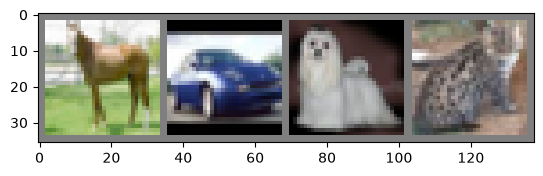

horse car   dog   cat  


In [4]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

## 2. Define the CNN

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net().to(device)


## 3. Loss function and optimizer

In [6]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

## 4. Train the Network

In [7]:
for epoch in range(2):

    running_loss = 0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        ##print statistics
        running_loss += loss.item()
        if i%2000 == 1999:
            print(f"[{epoch+1}, {i+1:5d}] loss: {running_loss / 2000 :.3f}")
            running_loss = 0.0

print("Finished Training")

[1,  2000] loss: 2.213
[1,  4000] loss: 1.924
[1,  6000] loss: 1.723
[1,  8000] loss: 1.625
[1, 10000] loss: 1.547
[1, 12000] loss: 1.483
[2,  2000] loss: 1.421
[2,  4000] loss: 1.417
[2,  6000] loss: 1.393
[2,  8000] loss: 1.332
[2, 10000] loss: 1.304
[2, 12000] loss: 1.290
Finished Training


Save the model

In [8]:
PATH = './cifar_net.pt'
torch.save(net.state_dict(), PATH)

## 5. Test the network

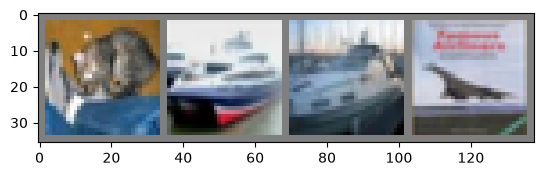

GroundTruth:  cat   ship  ship  plane


In [9]:
dataiter = iter(testloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [14]:
net = Net().to(device)
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [15]:
outputs = net(images)

In [16]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  cat   ship  plane plane


In [17]:
correct = 0
total = 0

with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 54 %


In [18]:
##count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        ##collect correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')


Accuracy for class: plane is 60.6 %
Accuracy for class: car   is 49.7 %
Accuracy for class: bird  is 38.0 %
Accuracy for class: cat   is 37.6 %
Accuracy for class: deer  is 43.1 %
Accuracy for class: dog   is 41.9 %
Accuracy for class: frog  is 73.2 %
Accuracy for class: horse is 70.3 %
Accuracy for class: ship  is 60.1 %
Accuracy for class: truck is 74.2 %
